# Homework 1 – Task 1: Data Download

In Task 1, we collected data for our assigned 250 firms. For each company, we downloaded daily adjusted close prices and trading volume from Yahoo Finance, and Market Capitalization together with Book Value per Share from Macrotrends. The sample period covers January 1, 2010 to February 28, 2026. The purpose of this task is to create a clean and complete dataset that can be used later in the portfolio analysis and stock index construction.

In [1]:
#install.packages("PerformanceAnalytics")
#install.packages("PortfolioAnalytics")
#install.packages("ROI.plugin.quadprog")
#install.packages("ROI.plugin.glpk")


In [2]:
options(warn = -1)
suppressPackageStartupMessages({
  library(quantmod)
  library(readr)
  library(dplyr)
  library(tibble)
  library(httr)
  library(rvest)
  library(xml2)
  library(stringr)
  library(purrr)
  library(jsonlite)
  library(xts)
  library(quantmod)
  library(PerformanceAnalytics)
  library(PortfolioAnalytics)
  library(ROI)
  library(ROI.plugin.quadprog)
  library(ROI.plugin.glpk)
})

In [3]:
tickers_df <- read_csv("61924783_data_download.csv", show_col_types = FALSE)
tickers <- tickers_df$x |> as.character() |> na.omit() |> unique()

length(tickers)
head(tickers, 10)

New names:
• `` -> `...1`


[1] 250

[1] "CL"   "GOOG" "HIG"  "NI"   "ALGN" "OKE"  "PGR"  "MCO"  "T"    "HSIC"

In [4]:
dir.create("data_yahoo", showWarnings = FALSE)
dir.create("data_book_value", showWarnings = FALSE)
dir.create("data_market_cap", showWarnings = FALSE)
dir.create("logs", showWarnings = FALSE)

In [5]:
ua_string <- paste(
  "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
  "AppleWebKit/537.36 (KHTML, like Gecko)",
  "Chrome/123.0.0.0 Safari/537.36"
)

clean_names_simple <- function(x) {
  x |>
    stringr::str_trim() |>
    stringr::str_replace_all("[^A-Za-z0-9]+", "_") |>
    stringr::str_replace_all("_+", "_") |>
    stringr::str_to_lower() |>
    stringr::str_replace("^_", "") |>
    stringr::str_replace("_$", "")
}

clean_num <- function(x) {
  x |>
    as.character() |>
    stringr::str_replace_all(",", "") |>
    stringr::str_replace_all("\\$", "") |>
    stringr::str_replace_all("%", "") |>
    stringr::str_trim() |>
    dplyr::na_if("") |>
    as.numeric()
}

normalize_macrotrends_ticker <- function(ticker) {
  dplyr::case_when(
    ticker %in% c("BRK-B", "BF-B") ~ stringr::str_replace_all(ticker, "-", "."),
    TRUE ~ ticker
  )
}

get_macrotrends_slug <- function(ticker, ua = ua_string) {
  mt_ticker <- normalize_macrotrends_ticker(ticker)
  start_url <- paste0("https://www.macrotrends.net/stocks/charts/", mt_ticker)

  resp <- GET(start_url, user_agent(ua), timeout(30))
  final_url <- resp$url

  parts <- str_split(final_url, "/", simplify = TRUE)
  idx <- which(parts == mt_ticker)

  if (length(idx) == 0) {
    stop("Could not locate ticker in redirected URL for ", ticker)
  }

  slug <- parts[idx[1] + 1]

  if (is.na(slug) || slug == "" || slug == mt_ticker) {
    stop("Could not resolve company slug for ", ticker)
  }

  slug
}

In [6]:
download_one_yahoo <- function(ticker,
                               from = "2010-01-01",
                               to   = "2026-02-28") {
  x <- suppressWarnings(
    getSymbols(
      ticker,
      src = "yahoo",
      from = from,
      to = to,
      auto.assign = FALSE
    )
  )

  tibble(
    date = as.Date(index(x)),
    ticker = ticker,
    adjusted = as.numeric(Ad(x)),
    volume = as.numeric(Vo(x))
  )
}

In [7]:
results_yahoo <- vector("list", length(tickers))

log_yahoo <- tibble(
  ticker = tickers,
  status = NA_character_,
  nrows = NA_integer_,
  error = NA_character_
)

for (i in seq_along(tickers)) {
  tk <- tickers[i]

  tryCatch({
    df <- download_one_yahoo(tk)

    write_csv(df, file.path("data_yahoo", paste0(tk, "_yahoo.csv")))
    results_yahoo[[i]] <- df

    log_yahoo$status[i] <- "ok"
    log_yahoo$nrows[i] <- nrow(df)
    log_yahoo$error[i] <- NA_character_

  }, error = function(e) {
    log_yahoo$status[i] <- "fail"
    log_yahoo$nrows[i] <- NA_integer_
    log_yahoo$error[i] <- conditionMessage(e)
  })
}

write_csv(log_yahoo, "logs/yahoo_download_log.csv")

all_yahoo <- bind_rows(results_yahoo)
write_csv(all_yahoo, "data_yahoo/all_yahoo_data.csv")
str(all_yahoo)

log_yahoo %>% count(status)

tibble [1,006,342 × 4] (S3: tbl_df/tbl/data.frame)
 $ date    : Date[1:1006342], format: "2010-01-04" "2010-01-05" ...
 $ ticker  : chr [1:1006342] "CL" "CL" "CL" "CL" ...
 $ adjusted: num [1:1006342] 28.2 28.5 28.4 28.3 27.8 ...
 $ volume  : num [1:1006342] 4874200 5296800 7195200 3752200 8150200 ...


status,n
<chr>,<int>
ok,250


In [8]:
get_book_value_table <- function(ticker, slug, ua = ua_string) {
  mt_ticker <- normalize_macrotrends_ticker(ticker)

  url <- paste0(
    "https://www.macrotrends.net/stocks/charts/",
    mt_ticker, "/", slug, "/price-book"
  )

  resp <- GET(url, user_agent(ua), timeout(30))

  if (status_code(resp) != 200) {
    stop("HTTP status ", status_code(resp), " for ", ticker)
  }

  page <- read_html(resp)
  tables <- page %>%
    html_elements("table") %>%
    html_table(fill = TRUE)

  if (length(tables) == 0) {
    stop("No tables found for ", ticker)
  }

  tbl <- tables[[1]]

  if (nrow(tbl) < 2) {
    stop("Book value table too short for ", ticker)
  }

  true_headers <- tbl[1, ] |> unlist() |> as.character() |> clean_names_simple()
  tbl <- tbl[-1, , drop = FALSE]
  names(tbl) <- true_headers

  tbl <- tbl[, 1:min(4, ncol(tbl)), drop = FALSE]

  current_names <- names(tbl)
  if (length(current_names) >= 1) current_names[1] <- "date"
  if (length(current_names) >= 2) current_names[2] <- "stock_price"
  if (length(current_names) >= 3) current_names[3] <- "book_value_per_share"
  if (length(current_names) >= 4) current_names[4] <- "price_to_book_ratio"
  names(tbl) <- current_names

  tbl$date <- as.Date(tbl$date)
  if ("stock_price" %in% names(tbl)) tbl$stock_price <- clean_num(tbl$stock_price)
  if ("book_value_per_share" %in% names(tbl)) tbl$book_value_per_share <- clean_num(tbl$book_value_per_share)
  if ("price_to_book_ratio" %in% names(tbl)) tbl$price_to_book_ratio <- clean_num(tbl$price_to_book_ratio)

  tbl <- tbl %>%
    mutate(
      ticker = ticker,
      slug = slug
    ) %>%
    select(ticker, slug, everything())

  tbl
}

In [9]:
existing_book <- list.files(
  "data_book_value",
  pattern = "_book_value\\.csv$",
  full.names = FALSE
)

done_book <- basename(existing_book) |> str_remove("_book_value\\.csv$")

log_book <- tibble(
  ticker = tickers,
  slug = NA_character_,
  status = ifelse(tickers %in% done_book, "already_saved", NA_character_),
  nrows = NA_integer_,
  error = NA_character_
)

for (i in seq_along(tickers)) {
  tk <- tickers[i]

  if (tk %in% done_book) next

  tryCatch({
    slug_i <- get_macrotrends_slug(tk)
    df_i <- get_book_value_table(tk, slug_i)

    write_csv(df_i, file.path("data_book_value", paste0(tk, "_book_value.csv")))

    log_book$slug[i] <- slug_i
    log_book$status[i] <- "ok"
    log_book$nrows[i] <- nrow(df_i)
    log_book$error[i] <- NA_character_

  }, error = function(e) {
    log_book$status[i] <- "fail"
    log_book$nrows[i] <- NA_integer_
    log_book$error[i] <- conditionMessage(e)
  })

  write_csv(log_book, "logs/book_value_log.csv")
  Sys.sleep(sample(35:45, 1))
}

write_csv(log_book, "logs/book_value_log.csv")
log_book %>% count(status)

status,n
<chr>,<int>
already_saved,250


In [10]:
get_market_cap_series <- function(ticker, ua = ua_string,
                                  start_date = as.Date("2010-01-01"),
                                  end_date   = as.Date("2026-02-28")) {

  mt_ticker <- normalize_macrotrends_ticker(ticker)

  url <- paste0(
    "https://www.macrotrends.net/assets/php/market_cap.php?t=",
    utils::URLencode(mt_ticker, reserved = TRUE)
  )

  resp <- httr::GET(url, httr::user_agent(ua), httr::timeout(30))

  if (httr::status_code(resp) != 200) {
    stop("HTTP status ", httr::status_code(resp), " for ", ticker)
  }

  raw_txt <- httr::content(resp, as = "text", encoding = "UTF-8")
  raw_txt <- stringr::str_replace_all(raw_txt, "[\r\n\t]", "")

  json_str <- stringr::str_extract(
    raw_txt,
    "(?s)(?<=\\=)\\s*\\[.*?\\](?=\\s*;)"
  )

  if (is.na(json_str)) {
    stop("Could not extract JSON payload for ", ticker)
  }

  dat <- jsonlite::fromJSON(json_str)

  if (is.data.frame(dat) || is.matrix(dat)) {
    if (ncol(dat) < 2) stop("Parsed payload has fewer than 2 columns for ", ticker)
    date_vec <- dat[, 1]
    value_vec <- dat[, 2]
  } else if (is.list(dat) && length(dat) > 0) {
    date_vec <- vapply(dat, function(x) as.character(x[[1]]), character(1))
    value_vec <- vapply(dat, function(x) as.numeric(x[[2]]), numeric(1))
  } else {
    stop("Unexpected payload structure for ", ticker)
  }

  tibble(
    ticker = ticker,
    macrotrends_ticker = mt_ticker,
    date = as.Date(date_vec),
    market_cap = as.numeric(value_vec) * 1000
  ) %>%
    filter(!is.na(date), !is.na(market_cap)) %>%
    filter(date >= start_date, date <= end_date) %>%
    distinct(date, .keep_all = TRUE) %>%
    arrange(desc(date))
}

In [11]:
download_market_cap_retry <- function(ticker, max_attempts = 4, wait_seconds = 60) {
  last_error <- NA_character_

  for (attempt in seq_len(max_attempts)) {
    res <- tryCatch({
      df <- get_market_cap_series(ticker)
      list(ok = TRUE, data = df, error = NA_character_)
    }, error = function(e) {
      list(ok = FALSE, data = NULL, error = conditionMessage(e))
    })

    if (isTRUE(res$ok)) return(res)

    last_error <- res$error

    if (attempt < max_attempts) {
      Sys.sleep(wait_seconds * attempt)
    }
  }

  list(ok = FALSE, data = NULL, error = last_error)
}

In [12]:
existing_mcap <- list.files(
  "data_market_cap",
  pattern = "_market_cap\\.csv$",
  full.names = FALSE
)

done_mcap <- basename(existing_mcap) |> str_remove("_market_cap\\.csv$")

log_mcap <- tibble(
  ticker = tickers,
  macrotrends_ticker = NA_character_,
  status = ifelse(tickers %in% done_mcap, "already_saved", NA_character_),
  nrows = NA_integer_,
  error = NA_character_
)

pending_tickers <- setdiff(tickers, done_mcap)

for (tk in pending_tickers) {
  row_i <- match(tk, log_mcap$ticker)

  res <- download_market_cap_retry(tk, max_attempts = 4, wait_seconds = 60)

  if (isTRUE(res$ok)) {
    df_i <- res$data

    write_csv(df_i, file.path("data_market_cap", paste0(tk, "_market_cap.csv")))

    log_mcap$macrotrends_ticker[row_i] <- unique(df_i$macrotrends_ticker)[1]
    log_mcap$status[row_i] <- "ok"
    log_mcap$nrows[row_i] <- nrow(df_i)
    log_mcap$error[row_i] <- NA_character_
  } else {
    log_mcap$status[row_i] <- "fail"
    log_mcap$nrows[row_i] <- NA_integer_
    log_mcap$error[row_i] <- res$error
  }

  write_csv(log_mcap, "logs/market_cap_log_retry.csv")
  Sys.sleep(sample(35:45, 1))
}

write_csv(log_mcap, "logs/market_cap_log_retry.csv")
log_mcap %>% count(status)

status,n
<chr>,<int>
already_saved,250


In [13]:
read_book_file <- function(path) {
  df <- read_csv(
    path,
    show_col_types = FALSE,
    col_types = cols(.default = col_character())
  )

  expected_cols <- c(
    "ticker", "slug", "date",
    "stock_price", "book_value_per_share", "price_to_book_ratio"
  )

  for (nm in setdiff(expected_cols, names(df))) {
    df[[nm]] <- NA_character_
  }

  df <- df[, expected_cols]

  df %>%
    mutate(
      ticker = as.character(ticker),
      slug = as.character(slug),
      date = as.Date(date),
      stock_price = as.numeric(stock_price),
      book_value_per_share = as.numeric(book_value_per_share),
      price_to_book_ratio = as.numeric(price_to_book_ratio)
    )
}



In [14]:
read_mcap_file <- function(path) {
  df <- read_csv(
    path,
    show_col_types = FALSE,
    col_types = cols(.default = col_character())
  )

  expected_cols <- c("ticker", "macrotrends_ticker", "date", "market_cap")

  for (nm in setdiff(expected_cols, names(df))) {
    df[[nm]] <- NA_character_
  }

  df <- df[, expected_cols]

  df %>%
    mutate(
      ticker = as.character(ticker),
      macrotrends_ticker = as.character(macrotrends_ticker),
      date = as.Date(date),
      market_cap = as.numeric(market_cap)
    )
}



In [15]:
# ------------------------------
# COMBINE CLEAN DATASETS
# ------------------------------
book_files <- list.files(
  "data_book_value",
  pattern = "_book_value\\.csv$",
  full.names = TRUE
)
book_files <- book_files[basename(book_files) != "all_book_value.csv"]

all_book_value <- purrr::map_dfr(book_files, read_book_file) %>%
  filter(date >= as.Date("2010-01-01"),
         date <= as.Date("2026-02-28"))

write_csv(all_book_value, "data_book_value/all_book_value.csv")

mcap_files <- list.files(
  "data_market_cap",
  pattern = "_market_cap\\.csv$",
  full.names = TRUE
)
mcap_files <- mcap_files[basename(mcap_files) != "all_market_cap.csv"]

all_market_cap <- purrr::map_dfr(mcap_files, read_mcap_file) %>%
  filter(date >= as.Date("2010-01-01"),
         date <= as.Date("2026-02-28"))

write_csv(all_market_cap, "data_market_cap/all_market_cap.csv")

In [16]:
library(readr)
library(dplyr)
library(stringr)

# ------------------------------
# FINAL VALIDATION FOR TASK 1
# ------------------------------
assigned_tickers <- read_csv("61924783_data_download.csv", show_col_types = FALSE)$x %>%
  as.character() %>%
  na.omit() %>%
  unique()

yahoo_files <- list.files("data_yahoo", pattern = "_yahoo\\.csv$", full.names = FALSE)
book_files  <- list.files("data_book_value", pattern = "_book_value\\.csv$", full.names = FALSE)
mcap_files  <- list.files("data_market_cap", pattern = "_market_cap\\.csv$", full.names = FALSE)

book_files <- setdiff(book_files, "all_book_value.csv")
mcap_files <- setdiff(mcap_files, "all_market_cap.csv")

yahoo_tickers_saved <- str_remove(yahoo_files, "_yahoo\\.csv$")
book_tickers_saved  <- str_remove(book_files, "_book_value\\.csv$")
mcap_tickers_saved  <- str_remove(mcap_files, "_market_cap\\.csv$")

missing_yahoo <- setdiff(assigned_tickers, yahoo_tickers_saved)
missing_book  <- setdiff(assigned_tickers, book_tickers_saved)
missing_mcap  <- setdiff(assigned_tickers, mcap_tickers_saved)

all_yahoo <- read_csv("data_yahoo/all_yahoo_data.csv", show_col_types = FALSE) %>%
  mutate(date = as.Date(date))

all_book_value <- read_csv("data_book_value/all_book_value.csv", show_col_types = FALSE) %>%
  mutate(date = as.Date(date))

all_market_cap <- read_csv("data_market_cap/all_market_cap.csv", show_col_types = FALSE) %>%
  mutate(date = as.Date(date))

outside_yahoo <- all_yahoo %>%
  filter(date < as.Date("2010-01-01") | date > as.Date("2026-02-28"))

outside_book <- all_book_value %>%
  filter(date < as.Date("2010-01-01") | date > as.Date("2026-02-28"))

outside_mcap <- all_market_cap %>%
  filter(date < as.Date("2010-01-01") | date > as.Date("2026-02-28"))

dup_yahoo <- all_yahoo %>%
  count(ticker, date) %>%
  filter(n > 1)

dup_book <- all_book_value %>%
  count(ticker, date) %>%
  filter(n > 1)

dup_mcap <- all_market_cap %>%
  count(ticker, date) %>%
  filter(n > 1)

cat("Assigned tickers:", length(assigned_tickers), "\n")
cat("Yahoo files:", length(yahoo_tickers_saved), "\n")
cat("Book value files:", length(book_tickers_saved), "\n")
cat("Market cap files:", length(mcap_tickers_saved), "\n\n")

cat("Missing Yahoo:", length(missing_yahoo), "\n")
cat("Missing Book Value:", length(missing_book), "\n")
cat("Missing Market Cap:", length(missing_mcap), "\n\n")

cat("Unique Yahoo tickers:", n_distinct(all_yahoo$ticker), "\n")
cat("Unique Book Value tickers:", n_distinct(all_book_value$ticker), "\n")
cat("Unique Market Cap tickers:", n_distinct(all_market_cap$ticker), "\n\n")

cat("Yahoo date range:", min(all_yahoo$date, na.rm = TRUE), "to", max(all_yahoo$date, na.rm = TRUE), "\n")
cat("Book Value date range:", min(all_book_value$date, na.rm = TRUE), "to", max(all_book_value$date, na.rm = TRUE), "\n")
cat("Market Cap date range:", min(all_market_cap$date, na.rm = TRUE), "to", max(all_market_cap$date, na.rm = TRUE), "\n\n")

cat("Rows outside range - Yahoo:", nrow(outside_yahoo), "\n")
cat("Rows outside range - Book Value:", nrow(outside_book), "\n")
cat("Rows outside range - Market Cap:", nrow(outside_mcap), "\n\n")

cat("Duplicate ticker-date rows - Yahoo:", nrow(dup_yahoo), "\n")
cat("Duplicate ticker-date rows - Book Value:", nrow(dup_book), "\n")
cat("Duplicate ticker-date rows - Market Cap:", nrow(dup_mcap), "\n\n")

task1_ok <- (
  length(assigned_tickers) == 250 &&
  length(yahoo_tickers_saved) == 250 &&
  length(book_tickers_saved) == 250 &&
  length(mcap_tickers_saved) == 250 &&
  length(missing_yahoo) == 0 &&
  length(missing_book) == 0 &&
  length(missing_mcap) == 0 &&
  n_distinct(all_yahoo$ticker) == 250 &&
  n_distinct(all_book_value$ticker) == 250 &&
  n_distinct(all_market_cap$ticker) == 250 &&
  nrow(outside_yahoo) == 0 &&
  nrow(outside_book) == 0 &&
  nrow(outside_mcap) == 0 &&
  nrow(dup_yahoo) == 0 &&
  nrow(dup_book) == 0 &&
  nrow(dup_mcap) == 0
)

cat("=====================================\n")
if (task1_ok) {
  cat("TASK 1 DATA CHECK PASSED\n")
} else {
  cat("TASK 1 DATA CHECK NOT FULLY PASSED\n")
}
cat("=====================================\n")

New names:
• `` -> `...1`


Assigned tickers: 250 
Yahoo files: 250 
Book value files: 250 
Market cap files: 250 

Missing Yahoo: 0 
Missing Book Value: 0 
Missing Market Cap: 0 

Unique Yahoo tickers: 250 
Unique Book Value tickers: 250 
Unique Market Cap tickers: 250 

Yahoo date range: 14613 to 20511 
Book Value date range: 14640 to 20512 
Market Cap date range: 14613 to 20511 

Rows outside range - Yahoo: 0 
Rows outside range - Book Value: 0 
Rows outside range - Market Cap: 0 

Duplicate ticker-date rows - Yahoo: 0 
Duplicate ticker-date rows - Book Value: 0 
Duplicate ticker-date rows - Market Cap: 0 

TASK 1 DATA CHECK PASSED


### Task 1 summary

The final validation confirms that Task 1 was completed successfully. We obtained data for all 250 assigned firms in all three datasets, with no missing tickers, no observations outside the required sample period, and no duplicate ticker-date rows. Therefore, the dataset is ready to be used in the following parts of the homework.

# Homework 1 – Task 2: Portfolio Analysis

In Task 2, we use the 20 assigned stocks from the random download file and split them into two portfolios. Portfolio A contains stocks 1–10 and Portfolio B contains stocks 11–20. Using adjusted close prices from Yahoo Finance, we convert daily prices into monthly returns and focus on the period from 2015 to 2024. The goal is to compare the two portfolios in a Markowitz framework by computing the global minimum variance portfolio (GMVP) and the efficient frontier for each portfolio.

In [17]:
# TASK 2: correct 20 tickers
# ------------------------------
rand_download <- read_csv("61924783_rand_download.csv", show_col_types = FALSE)


tickers20 <- rand_download[[2]] %>%
  as.character() %>%
  na.omit()

stopifnot(length(tickers20) == 20)

tickers_A <- tickers20[1:10]
tickers_B <- tickers20[11:20]

tickers20
tickers_A
tickers_B

New names:
• `` -> `...1`


[1] "FFIV" "MA"   "IVZ"  "CCL"  "FSLR" "SPG"  "PHM"  "STLD" "FANG" "NOW" 
[11] "TSN"  "AMZN" "WBD"  "USB"  "HUBB" "NDAQ" "RF"   "JBL"  "CI"   "HUM"

[1] "FFIV" "MA"   "IVZ"  "CCL"  "FSLR" "SPG"  "PHM"  "STLD" "FANG" "NOW"

[1] "TSN"  "AMZN" "WBD"  "USB"  "HUBB" "NDAQ" "RF"   "JBL"  "CI"   "HUM"

In [18]:
all_yahoo <- read_csv("data_yahoo/all_yahoo_data.csv", show_col_types = FALSE) %>%
  mutate(
    date = as.Date(date),
    ticker = as.character(ticker),
    adjusted = as.numeric(adjusted)
  ) %>%
  arrange(ticker, date)

In [19]:
make_monthly_returns <- function(data, tickers,
                                 start_date = "2015-01-01",
                                 end_date   = "2024-12-31") {

  ret_list <- lapply(tickers, function(tk) {
    df_tk <- data %>%
      filter(
        ticker == tk,
        date >= as.Date(start_date),
        date <= as.Date(end_date)
      ) %>%
      arrange(date)

    if (nrow(df_tk) == 0) stop(paste("No daily data for", tk))

    px_xts <- xts(df_tk$adjusted, order.by = df_tk$date)
    colnames(px_xts) <- tk

    # monthly adjusted close
    px_monthly <- to.monthly(px_xts, indexAt = "lastof", OHLC = FALSE)

    # simple monthly returns
    ret_monthly <- Return.calculate(px_monthly, method = "discrete")
    ret_monthly <- ret_monthly[-1, , drop = FALSE]  # remove first NA
    colnames(ret_monthly) <- tk

    ret_monthly
  })

  R <- do.call(merge, ret_list)
  R <- na.omit(R)

  return(R)
}

R_A <- make_monthly_returns(all_yahoo, tickers_A)
R_B <- make_monthly_returns(all_yahoo, tickers_B)

head(R_A)
head(R_B)

                  FFIV          MA         IVZ          CCL          FSLR
2015-02-28  0.05823329  0.09874430  0.10335859  0.006494963  0.4118620140
2015-03-31 -0.02692178 -0.04149545 -0.01440272  0.087520014  0.0006694714
2015-04-30  0.06159730  0.04613463  0.04358749 -0.080894783 -0.0020070705
2015-05-31  0.03007708  0.02272479 -0.03198420  0.059148427 -0.1669180390
2015-06-30 -0.04248551  0.01322327 -0.05874988  0.066047820 -0.0549185193
2015-07-31  0.11458248  0.04370103  0.02960846  0.078963467 -0.0570455584
                    SPG          PHM        STLD        FANG         NOW
2015-02-28 -0.034841337  0.095677183  0.06924855  0.03217857  0.04609053
2015-03-31  0.027736591 -0.010921774  0.11084442  0.07906167  0.03304483
2015-04-30 -0.072326645 -0.131803761  0.10099501  0.07457045 -0.04975879
2015-05-31  0.007700007 -0.006217326 -0.01446003 -0.05764791  0.02337693
2015-06-30 -0.046196094  0.055041486 -0.04402096 -0.03122968 -0.03002213
2015-07-31  0.082071261  0.028287639 -0.0333

                    TSN        AMZN          WBD          USB         HUBB
2015-02-28  0.060701247  0.07229289  0.114177285  0.064423873  0.078372455
2015-03-31 -0.072863460 -0.02120159 -0.047677989 -0.015494757 -0.036730716
2015-04-30  0.031331328  0.13351256  0.052015617 -0.018318985 -0.007206922
2015-05-31  0.077204467  0.01766321  0.048825649  0.005598243 -0.002261262
2015-06-30  0.004240521  0.01132260 -0.020035366  0.012521349  0.002314155
2015-07-31  0.040346803  0.23511256 -0.007215811  0.041704888 -0.035740429
                  NDAQ           RF         JBL          CI         HUM
2015-02-28  0.10000013  0.104597242  0.06995684  0.13853779  0.12250738
2015-03-31  0.01862841 -0.011473681  0.06417834  0.06456002  0.08470694
2015-04-30 -0.04534750  0.040211763 -0.03678334 -0.03708265 -0.06976766
2015-05-31  0.06415782  0.026449283  0.09477301  0.12989397  0.29619604
2015-06-30 -0.05208523  0.032632153 -0.13349622  0.15032287 -0.10756378
2015-07-31  0.04548258  0.002896101 -0.0488

In [20]:
# ------------------------------
# STEP 1: Understand the inputs
# ------------------------------

library(dplyr)
library(tibble)

# basic checks
dim(R_A)
dim(R_B)

sum(is.na(R_A))
sum(is.na(R_B))

# summary by stock: average monthly return and monthly volatility
summary_A <- tibble(
  ticker = colnames(R_A),
  mean_monthly_return = as.numeric(colMeans(R_A)),
  sd_monthly = as.numeric(apply(R_A, 2, sd))
) %>%
  arrange(desc(mean_monthly_return))

summary_B <- tibble(
  ticker = colnames(R_B),
  mean_monthly_return = as.numeric(colMeans(R_B)),
  sd_monthly = as.numeric(apply(R_B, 2, sd))
) %>%
  arrange(desc(mean_monthly_return))

summary_A
summary_B

# correlation matrices: how stocks move together
cor_A <- cor(R_A)
cor_B <- cor(R_B)

round(cor_A, 2)
round(cor_B, 2)

# covariance matrices: direct input for portfolio optimization
Sigma_A <- cov(R_A)
Sigma_B <- cov(R_B)

round(Sigma_A, 4)
round(Sigma_B, 4)

[1] 119  10

[1] 119  10

[1] 0

[1] 0

ticker,mean_monthly_return,sd_monthly
<chr>,<dbl>,<dbl>
NOW,0.026427336,0.08675470
STLD,0.023531017,0.10740362
FSLR,0.022371670,0.14916265
PHM,0.020310694,0.09911929
FANG,0.018665931,0.13733088
MA,0.018376781,0.06539345
FFIV,0.009779395,0.07754241
CCL,0.008789685,0.15442337
SPG,0.008024633,0.09399506


ticker,mean_monthly_return,sd_monthly
<chr>,<dbl>,<dbl>
AMZN,0.0251534228,0.08857223
JBL,0.0214631167,0.09273093
NDAQ,0.0169761073,0.06044960
HUBB,0.0163828621,0.07609856
RF,0.0156702175,0.09312228
CI,0.0115757910,0.07798978
HUM,0.0087001591,0.08475297
TSN,0.0079506938,0.07573396
USB,0.0069279081,0.07617350


,FFIV,MA,IVZ,CCL,FSLR,SPG,PHM,STLD,FANG,NOW
FFIV,1.00,0.34,0.35,0.31,0.22,0.43,0.29,0.39,0.34,0.33
MA,0.34,1.00,0.38,0.56,0.20,0.45,0.49,0.38,0.42,0.50
IVZ,0.35,0.38,1.00,0.52,0.28,0.63,0.42,0.50,0.37,0.23
CCL,0.31,0.56,0.52,1.00,0.18,0.67,0.41,0.48,0.46,0.39
FSLR,0.22,0.20,0.28,0.18,1.00,0.25,0.22,0.23,0.17,0.22
SPG,0.43,0.45,0.63,0.67,0.25,1.00,0.51,0.44,0.59,0.27
PHM,0.29,0.49,0.42,0.41,0.22,0.51,1.00,0.30,0.32,0.32
STLD,0.39,0.38,0.50,0.48,0.23,0.44,0.30,1.00,0.39,0.21
FANG,0.34,0.42,0.37,0.46,0.17,0.59,0.32,0.39,1.00,0.18
NOW,0.33,0.50,0.23,0.39,0.22,0.27,0.32,0.21,0.18,1.00


,TSN,AMZN,WBD,USB,HUBB,NDAQ,RF,JBL,CI,HUM
TSN,1.00,0.14,0.30,0.40,0.23,0.39,0.31,0.19,0.27,0.10
AMZN,0.14,1.00,0.35,0.23,0.34,0.38,0.26,0.29,0.03,0.14
WBD,0.30,0.35,1.00,0.51,0.27,0.24,0.51,0.29,0.19,0.13
USB,0.40,0.23,0.51,1.00,0.42,0.40,0.84,0.36,0.40,0.19
HUBB,0.23,0.34,0.27,0.42,1.00,0.36,0.49,0.43,0.32,0.19
NDAQ,0.39,0.38,0.24,0.40,0.36,1.00,0.39,0.37,0.17,0.32
RF,0.31,0.26,0.51,0.84,0.49,0.39,1.00,0.35,0.36,0.25
JBL,0.19,0.29,0.29,0.36,0.43,0.37,0.35,1.00,0.26,0.17
CI,0.27,0.03,0.19,0.40,0.32,0.17,0.36,0.26,1.00,0.52
HUM,0.10,0.14,0.13,0.19,0.19,0.32,0.25,0.17,0.52,1.00


,FFIV,MA,IVZ,CCL,FSLR,SPG,PHM,STLD,FANG,NOW
FFIV,0.0060,0.0017,0.0029,0.0037,0.0025,0.0031,0.0022,0.0032,0.0036,0.0022
MA,0.0017,0.0043,0.0026,0.0057,0.0019,0.0028,0.0032,0.0027,0.0038,0.0029
IVZ,0.0029,0.0026,0.0113,0.0086,0.0044,0.0063,0.0045,0.0057,0.0054,0.0021
CCL,0.0037,0.0057,0.0086,0.0238,0.0041,0.0097,0.0063,0.0079,0.0097,0.0053
FSLR,0.0025,0.0019,0.0044,0.0041,0.0222,0.0035,0.0033,0.0037,0.0035,0.0028
SPG,0.0031,0.0028,0.0063,0.0097,0.0035,0.0088,0.0048,0.0044,0.0076,0.0022
PHM,0.0022,0.0032,0.0045,0.0063,0.0033,0.0048,0.0098,0.0031,0.0044,0.0028
STLD,0.0032,0.0027,0.0057,0.0079,0.0037,0.0044,0.0031,0.0115,0.0057,0.0020
FANG,0.0036,0.0038,0.0054,0.0097,0.0035,0.0076,0.0044,0.0057,0.0189,0.0022
NOW,0.0022,0.0029,0.0021,0.0053,0.0028,0.0022,0.0028,0.0020,0.0022,0.0075


,TSN,AMZN,WBD,USB,HUBB,NDAQ,RF,JBL,CI,HUM
TSN,0.0057,0.0010,0.0030,0.0023,0.0013,0.0018,0.0022,0.0013,0.0016,0.0006
AMZN,0.0010,0.0078,0.0041,0.0016,0.0023,0.0020,0.0022,0.0023,0.0002,0.0010
WBD,0.0030,0.0041,0.0173,0.0051,0.0027,0.0019,0.0063,0.0035,0.0020,0.0015
USB,0.0023,0.0016,0.0051,0.0058,0.0024,0.0018,0.0059,0.0026,0.0024,0.0012
HUBB,0.0013,0.0023,0.0027,0.0024,0.0058,0.0017,0.0035,0.0030,0.0019,0.0013
NDAQ,0.0018,0.0020,0.0019,0.0018,0.0017,0.0037,0.0022,0.0020,0.0008,0.0017
RF,0.0022,0.0022,0.0063,0.0059,0.0035,0.0022,0.0087,0.0030,0.0026,0.0019
JBL,0.0013,0.0023,0.0035,0.0026,0.0030,0.0020,0.0030,0.0086,0.0019,0.0013
CI,0.0016,0.0002,0.0020,0.0024,0.0019,0.0008,0.0026,0.0019,0.0061,0.0035
HUM,0.0006,0.0010,0.0015,0.0012,0.0013,0.0017,0.0019,0.0013,0.0035,0.0072


### Input data and descriptive statistics

Both portfolios contain 10 stocks and the monthly return series covers 119 observations, which corresponds to the period from February 2015 to December 2024. There are no missing values in either return matrix, so both datasets are suitable for portfolio optimization.

The summary statistics show that the individual stocks differ substantially in both average monthly return and volatility. In Portfolio A, stocks such as NOW, STLD, and FSLR have the highest average monthly returns, but they are also relatively volatile. In Portfolio B, AMZN and JBL stand out with the highest average returns, while NDAQ combines a relatively attractive return with comparatively low volatility. The correlation matrices further indicate that diversification benefits are present in both portfolios, although some stock pairs move quite closely together.

In [21]:
# ------------------------------
# TASK 2: GMVP for portfolio A and B
# ------------------------------


get_gmvp <- function(R_xts) {
  assets <- colnames(R_xts)

  port <- portfolio.spec(assets = assets)

  # weights must sum to 1
  port <- add.constraint(portfolio = port, type = "full_investment")


  port <- add.constraint(portfolio = port, type = "box", min = -1, max = 1)

  # minimize portfolio volatility
  port <- add.objective(portfolio = port, type = "risk", name = "StdDev")

  gmvp <- optimize.portfolio(
    R = R_xts,
    portfolio = port,
    optimize_method = "ROI"
  )

  w <- extractWeights(gmvp)

  rp <- Return.portfolio(R_xts, weights = w, geometric = FALSE)

  list(
    model = gmvp,
    weights = w,
    mean = as.numeric(mean(rp)),
    sd = as.numeric(sd(rp)),
    min_weight = min(w)
  )
}

gmvp_A <- get_gmvp(R_A)
gmvp_B <- get_gmvp(R_B)

# weights
round(sort(gmvp_A$weights, decreasing = TRUE), 4)
round(sort(gmvp_B$weights, decreasing = TRUE), 4)

# summary stats
gmvp_A$mean
gmvp_A$sd
gmvp_A$min_weight

gmvp_B$mean
gmvp_B$sd
gmvp_B$min_weight

MA    FFIV     SPG     NOW    STLD     IVZ    FSLR     PHM    FANG     CCL 
 0.5245  0.2245  0.1835  0.1381  0.0694  0.0387  0.0246  0.0175 -0.0421 -0.1787

NDAQ     USB     TSN      CI    HUBB    AMZN     HUM     JBL     WBD      RF 
 0.2723  0.2120  0.1561  0.1472  0.1292  0.1270  0.1104  0.0269 -0.0207 -0.1603

[1] 0.01794678

[1] 0.05642375

[1] -0.1787009

[1] 0.01417703

[1] 0.04807479

[1] -0.1603246

### Global minimum variance portfolios

Next, we compute the global minimum variance portfolio for both sets of stocks. The GMVP is the portfolio with the lowest possible volatility among all feasible portfolios under the imposed constraints.

The results show that Portfolio B has the lower-risk GMVP, with a monthly standard deviation of about 4.81%, compared to about 5.64% for Portfolio A. On the other hand, Portfolio A offers a higher expected monthly return at the GMVP, approximately 1.79%, while Portfolio B reaches about 1.42%.

This means that Portfolio B is more attractive for a strongly risk-averse investor who mainly wants to minimize volatility. Portfolio A, however, provides a higher expected return even at its minimum-variance point, which may make it more appealing for an investor willing to accept slightly higher risk in exchange for better performance.

,target_return,mean,sd
,<dbl>,<dbl>,<dbl>
mean...1,0.01794678,0.01834100,0.05656763
mean...2,0.01824466,0.01850760,0.05664636
mean...3,0.01854254,0.01867168,0.05673400
mean...4,0.01884041,0.01883332,0.05682993
mean...5,0.01913829,0.01899260,0.05693361
mean...6,0.01943617,0.01914959,0.05704449
mean...7,0.01973405,0.01930435,0.05716210
mean...8,0.02003193,0.01945695,0.05728600
mean...9,0.02032981,0.01960746,0.05741575


,target_return,mean,sd
,<dbl>,<dbl>,<dbl>
mean...1,0.01417703,0.01477198,0.04863653
mean...2,0.01455873,0.01504517,0.04892565
mean...3,0.01494043,0.01531132,0.04922500
mean...4,0.01532213,0.01557079,0.04953286
mean...5,0.01570383,0.01582392,0.04984772
mean...6,0.01608553,0.01607101,0.05016829
mean...7,0.01646723,0.01631236,0.05049344
mean...8,0.01684893,0.01654822,0.05082218
mean...9,0.01723063,0.01677886,0.05115364


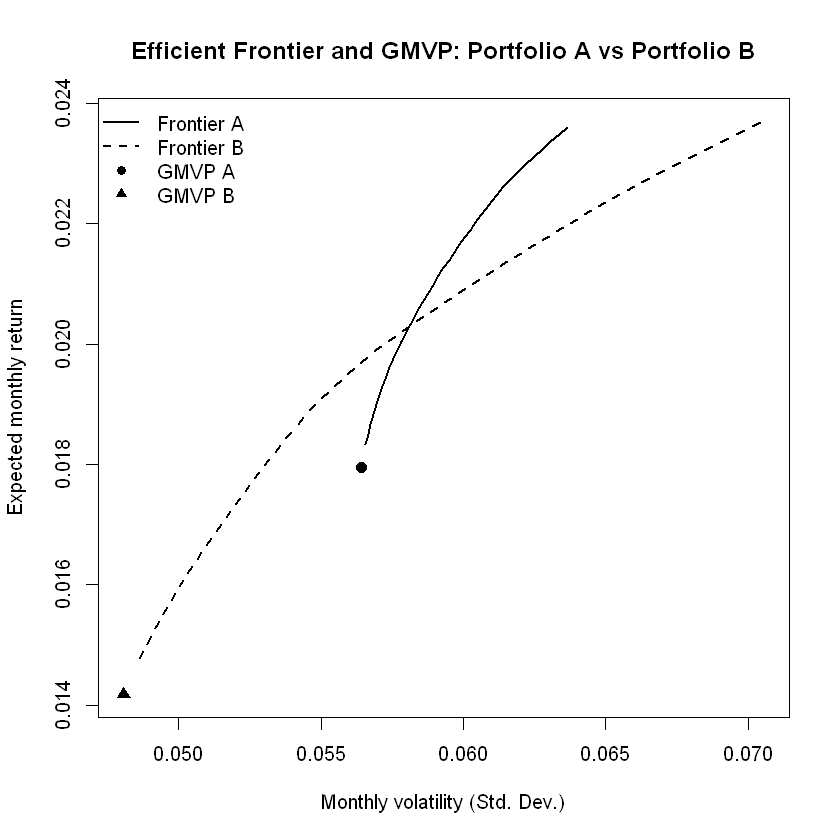

In [22]:
# ------------------------------
# TASK 2: Efficient frontier for portfolio A and B
# ------------------------------

portfolio_stats <- function(R_xts, w) {
  rp <- Return.portfolio(R_xts, weights = w, geometric = FALSE)
  c(
    mean = as.numeric(mean(rp)),
    sd   = as.numeric(sd(rp))
  )
}

get_max_return <- function(R_xts, min_w) {
  assets <- colnames(R_xts)

  port <- portfolio.spec(assets = assets)
  port <- add.constraint(portfolio = port, type = "full_investment")
  port <- add.constraint(portfolio = port, type = "box", min = min_w, max = 1)
  port <- add.objective(portfolio = port, type = "return", name = "mean")

  opt <- optimize.portfolio(
    R = R_xts,
    portfolio = port,
    optimize_method = "ROI"
  )

  w <- extractWeights(opt)
  stats <- portfolio_stats(R_xts, w)

  list(weights = w, mean = stats["mean"], sd = stats["sd"])
}

build_frontier <- function(R_xts, gmvp_mean, min_w, n_points = 40) {
  assets <- colnames(R_xts)

  max_ret_port <- get_max_return(R_xts, min_w)
  targets <- seq(gmvp_mean, max_ret_port$mean, length.out = n_points)

  frontier_list <- vector("list", length(targets))

  for (i in seq_along(targets)) {
    target_i <- targets[i]

    port_i <- portfolio.spec(assets = assets)
    port_i <- add.constraint(portfolio = port_i, type = "full_investment")
    port_i <- add.constraint(portfolio = port_i, type = "box", min = min_w, max = 1)
    port_i <- add.constraint(portfolio = port_i, type = "return", return_target = target_i)
    port_i <- add.objective(portfolio = port_i, type = "risk", name = "StdDev")

    opt_i <- try(
      optimize.portfolio(
        R = R_xts,
        portfolio = port_i,
        optimize_method = "ROI"
      ),
      silent = TRUE
    )

    if (!inherits(opt_i, "try-error")) {
      w_i <- extractWeights(opt_i)
      stats_i <- portfolio_stats(R_xts, w_i)

      frontier_list[[i]] <- data.frame(
        target_return = target_i,
        mean = stats_i["mean"],
        sd = stats_i["sd"]
      )
    }
  }

  frontier_df <- dplyr::bind_rows(frontier_list) %>%
    distinct(mean, sd, .keep_all = TRUE) %>%
    arrange(sd)

  frontier_df
}

# build frontiers
frontier_A <- build_frontier(
  R_xts = R_A,
  gmvp_mean = gmvp_A$mean,
  min_w = gmvp_A$min_weight,
  n_points = 40
)

frontier_B <- build_frontier(
  R_xts = R_B,
  gmvp_mean = gmvp_B$mean,
  min_w = gmvp_B$min_weight,
  n_points = 40
)

# ------------------------------
# final graph: both frontiers + both GMVP points
# ------------------------------
plot(
  frontier_A$sd, frontier_A$mean,
  type = "l", lwd = 2,
  xlab = "Monthly volatility (Std. Dev.)",
  ylab = "Expected monthly return",
  main = "Efficient Frontier and GMVP: Portfolio A vs Portfolio B",
  xlim = range(c(frontier_A$sd, frontier_B$sd, gmvp_A$sd, gmvp_B$sd)),
  ylim = range(c(frontier_A$mean, frontier_B$mean, gmvp_A$mean, gmvp_B$mean))
)

lines(frontier_B$sd, frontier_B$mean, lwd = 2, lty = 2)

points(gmvp_A$sd, gmvp_A$mean, pch = 19, cex = 1.2)
points(gmvp_B$sd, gmvp_B$mean, pch = 17, cex = 1.2)

legend(
  "topleft",
  legend = c("Frontier A", "Frontier B", "GMVP A", "GMVP B"),
  lty = c(1, 2, NA, NA),
  pch = c(NA, NA, 19, 17),
  lwd = c(2, 2, NA, NA),
  bty = "n"
)

# quick outputs for commentary
frontier_A
frontier_B

### Efficient frontier

After identifying the GMVP, we construct the efficient frontier for each portfolio. The efficient frontier shows the set of portfolios that deliver the highest expected return for a given level of risk.

The graph suggests that Portfolio B starts from a lower minimum-risk point, which confirms its better downside protection at the conservative end of the risk-return spectrum. However, Portfolio A becomes more attractive as risk increases, because its frontier lies above Portfolio B over a relevant part of the return range. In other words, Portfolio A appears to offer better return potential for investors who are willing to move away from the minimum-variance allocation and accept more volatility.

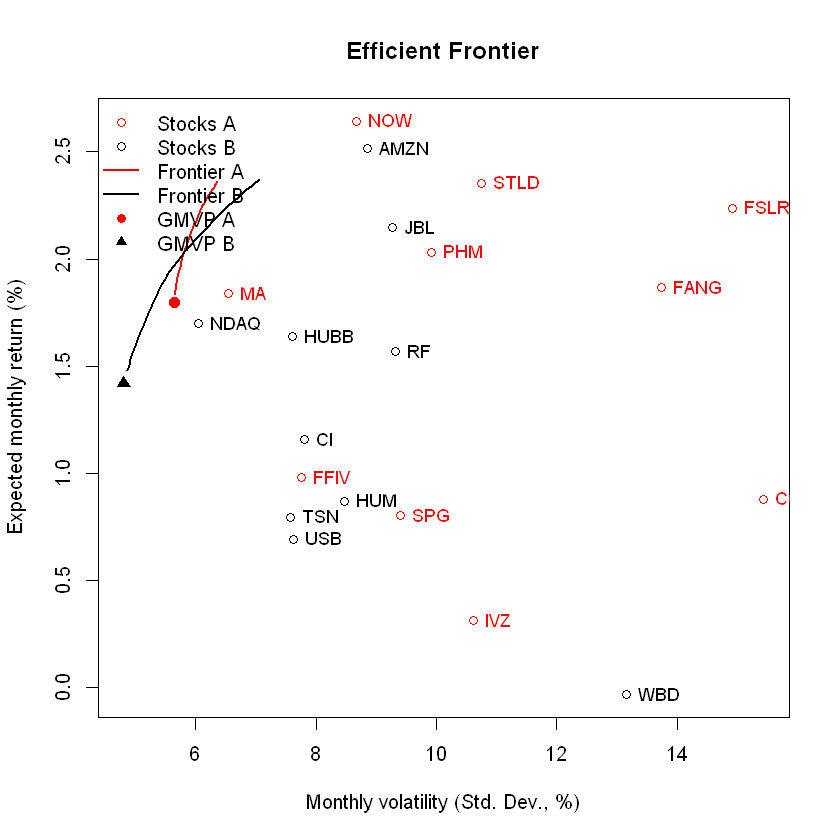

In [23]:
# ------------------------------
# stock summaries for plotting
# ------------------------------
stocks_A <- data.frame(
  ticker = colnames(R_A),
  mean = as.numeric(colMeans(R_A)),
  sd = as.numeric(apply(R_A, 2, sd)),
  group = "A"
)

stocks_B <- data.frame(
  ticker = colnames(R_B),
  mean = as.numeric(colMeans(R_B)),
  sd = as.numeric(apply(R_B, 2, sd)),
  group = "B"
)

stocks_all <- rbind(stocks_A, stocks_B)

# ------------------------------
# final graph: stocks + frontiers + GMVPs
# ------------------------------
plot(
  stocks_all$sd * 100, stocks_all$mean * 100,
  type = "n",
  xlab = "Monthly volatility (Std. Dev., %)",
  ylab = "Expected monthly return (%)",
  main = "Efficient Frontier",
  xlim = range(c(stocks_all$sd, frontier_A$sd, frontier_B$sd, gmvp_A$sd, gmvp_B$sd)) * 100,
  ylim = range(c(stocks_all$mean, frontier_A$mean, frontier_B$mean, gmvp_A$mean, gmvp_B$mean)) * 100
)

# individual stocks
points(stocks_A$sd * 100, stocks_A$mean * 100, pch = 1, col = "red")
points(stocks_B$sd * 100, stocks_B$mean * 100, pch = 1, col = "black")

text(stocks_A$sd * 100, stocks_A$mean * 100,
     labels = stocks_A$ticker, col = "red", pos = 4, cex = 0.9)

text(stocks_B$sd * 100, stocks_B$mean * 100,
     labels = stocks_B$ticker, col = "black", pos = 4, cex = 0.9)

# efficient frontiers
lines(frontier_A$sd * 100, frontier_A$mean * 100, lwd = 2, col = "red")
lines(frontier_B$sd * 100, frontier_B$mean * 100, lwd = 2, col = "black")

# GMVP points
points(gmvp_A$sd * 100, gmvp_A$mean * 100, pch = 19, cex = 1.2, col = "red")
points(gmvp_B$sd * 100, gmvp_B$mean * 100, pch = 17, cex = 1.2, col = "black")

legend(
  "topleft",
  legend = c("Stocks A", "Stocks B", "Frontier A", "Frontier B", "GMVP A", "GMVP B"),
  col = c("red", "black", "red", "black", "red", "black"),
  pch = c(1, 1, NA, NA, 19, 17),
  lty = c(NA, NA, 1, 1, NA, NA),
  lwd = c(NA, NA, 2, 2, NA, NA),
  bty = "n"
)

### Interpretation of the final graph

The final graph combines the individual stocks, the efficient frontiers, and the GMVPs of both portfolios. It shows that some stocks with high average returns are also associated with high volatility, which is consistent with the standard risk-return trade-off. At the same time, diversification shifts the feasible set inward, allowing the optimized portfolios to achieve a more favorable combination of return and risk than most individual stocks.

Overall, Portfolio B seems preferable for conservative investors because it achieves the lower minimum variance. Portfolio A, in contrast, appears more suitable for investors with a higher risk tolerance, since its efficient frontier reaches higher expected returns. Therefore, the choice between the two portfolios depends mainly on whether the investor prioritizes lower risk or higher return potential.

# Homework 1 – Task 3: Stock Index Construction

In Task 3, we use the monthly prices of the same 20 assigned stocks from Task 2 and construct three different stock indexes over the period 2015–2024. Specifically, we create a price-weighted index, a market-cap-weighted index, and an equally weighted index. The purpose of this task is to compare how different weighting schemes affect the evolution of an index over time.

In [24]:
# ------------------------------
# TASK 3 - STEP 1: load data
# ------------------------------
options(warn = -1)

suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(xts)
  library(quantmod)
  library(zoo)
})

# 20 stocks from the random download file
rand_download <- read_csv("61924783_rand_download.csv", show_col_types = FALSE)

tickers20 <- rand_download[[2]] %>%
  as.character() %>%
  na.omit()

length(tickers20)
tickers20

# Yahoo adjusted prices
all_yahoo <- read_csv("data_yahoo/all_yahoo_data.csv", show_col_types = FALSE) %>%
  mutate(
    date = as.Date(date),
    ticker = as.character(ticker),
    adjusted = as.numeric(adjusted)
  ) %>%
  arrange(ticker, date)

# Market capitalization
all_market_cap <- read_csv("data_market_cap/all_market_cap.csv", show_col_types = FALSE) %>%
  mutate(
    date = as.Date(date),
    ticker = as.character(ticker),
    market_cap = as.numeric(market_cap)
  ) %>%
  arrange(ticker, date)

New names:
• `` -> `...1`


[1] 20

[1] "FFIV" "MA"   "IVZ"  "CCL"  "FSLR" "SPG"  "PHM"  "STLD" "FANG" "NOW" 
[11] "TSN"  "AMZN" "WBD"  "USB"  "HUBB" "NDAQ" "RF"   "JBL"  "CI"   "HUM"

In [25]:
# ------------------------------
# STEP 2: monthly prices with YYYY-MM key
# ------------------------------
library(tidyr)
library(dplyr)

monthly_prices_df <- all_yahoo %>%
  filter(
    ticker %in% tickers20,
    date >= as.Date("2015-01-01"),
    date <= as.Date("2024-12-31")
  ) %>%
  mutate(ym = format(date, "%Y-%m")) %>%
  group_by(ticker, ym) %>%
  slice_max(order_by = date, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(ym, ticker, adjusted) %>%
  pivot_wider(names_from = ticker, values_from = adjusted) %>%
  arrange(ym)

dim(monthly_prices_df)
head(monthly_prices_df)
tail(monthly_prices_df)

[1] 120  21

ym,AMZN,CCL,CI,FANG,FFIV,FSLR,HUBB,HUM,IVZ,⋯,MA,NDAQ,NOW,PHM,RF,SPG,STLD,TSN,USB,WBD
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-01,17.7265,37.33549,97.0463,53.03210,111.62,42.32,83.66537,133.5928,22.45184,⋯,76.72585,12.68044,14.580,17.88854,5.886291,114.2217,13.44238,30.09093,28.21196,28.99
2015-02,19.0080,37.57799,110.4909,54.73859,118.12,59.75,90.22243,149.9589,24.77243,⋯,84.30209,13.94848,15.252,19.60006,6.501980,110.2421,14.37325,31.91749,30.02949,32.30
2015-03,18.6050,40.86681,117.6242,59.06632,114.94,59.79,86.90849,162.6615,24.41564,⋯,80.80394,14.20832,15.756,19.38600,6.427379,113.2998,15.96644,29.59187,29.56419,30.76
2015-04,21.0890,37.56090,113.2624,63.47092,122.02,59.67,86.28215,151.3130,25.47986,⋯,84.53180,13.56401,14.972,16.83085,6.685835,105.1052,17.57897,30.51902,29.02260,32.36
2015-05,21.4615,39.78257,127.9745,59.81195,125.69,49.71,86.08704,196.1313,24.66491,⋯,86.45277,14.43425,15.322,16.72621,6.862670,105.9145,17.32478,32.87523,29.18508,33.94
2015-06,21.7045,42.41012,147.2119,57.94405,120.35,46.98,86.28626,175.0346,23.21585,⋯,87.59595,13.68244,14.862,17.64684,7.086614,101.0217,16.56212,33.01464,29.55051,33.26


ym,AMZN,CCL,CI,FANG,FFIV,FSLR,HUBB,HUM,IVZ,⋯,MA,NDAQ,NOW,PHM,RF,SPG,STLD,TSN,USB,WBD
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-07,186.98,16.58334,337.0594,192.2722,203.64,215.99,387.0873,352.6098,16.00861,⋯,459.7581,66.22785,162.878,130.2428,20.81532,140.9413,129.9058,57.44522,41.64026,8.65
2024-08,178.50,16.42408,349.7619,187.6648,203.15,227.37,392.4755,345.6475,16.04616,⋯,479.2209,70.53345,171.000,129.8975,21.79235,153.7183,116.5369,61.12506,43.82062,7.84
2024-09,186.33,18.39497,336.1915,165.8214,220.20,249.44,420.3763,309.7143,16.48745,⋯,489.5917,71.68055,178.878,141.8219,21.94284,157.2114,123.3940,56.61031,42.90055,8.25
2024-10,186.40,21.89877,305.4971,170.0246,233.88,194.48,419.0808,252.1110,16.28089,⋯,495.9909,72.57398,186.598,127.9885,22.45073,157.3044,127.7198,55.68834,45.32091,8.13
2024-11,207.89,25.31299,327.8071,171.6611,250.35,199.27,452.8281,289.8059,17.18467,⋯,529.1008,81.47883,209.888,133.6602,25.63917,170.7728,142.1752,61.78498,49.99278,10.48
2024-12,219.39,24.80534,269.0961,158.3604,251.47,176.24,412.2784,248.9489,16.60520,⋯,522.7766,76.12706,212.024,107.8066,22.32629,162.0294,112.0929,55.02216,45.34046,10.57


### Monthly data preparation

First, we transform the daily data into monthly observations. For each stock, we keep the last available adjusted closing price in each month and the last available market capitalization in each month. This gives us a balanced monthly panel for all 20 stocks from January 2015 to December 2024. Using adjusted prices is useful because they already reflect stock splits and other price adjustments, which is especially important for index construction.

In [26]:
# ------------------------------
# STEP 3: monthly market cap with YYYY-MM key
# ------------------------------
monthly_mcap_df <- all_market_cap %>%
  filter(
    ticker %in% tickers20,
    date >= as.Date("2015-01-01"),
    date <= as.Date("2024-12-31")
  ) %>%
  mutate(ym = format(date, "%Y-%m")) %>%
  group_by(ticker, ym) %>%
  slice_max(order_by = date, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(ym, ticker, market_cap) %>%
  pivot_wider(names_from = ticker, values_from = market_cap) %>%
  arrange(ym)

dim(monthly_mcap_df)
head(monthly_mcap_df)
tail(monthly_mcap_df)

[1] 120  21

ym,AMZN,CCL,CI,FANG,FFIV,FSLR,HUBB,HUM,IVZ,⋯,MA,NDAQ,NOW,PHM,RF,SPG,STLD,TSN,USB,WBD
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-01,164860,34160,27420,4030,8060,4250,6150,22040,15460,⋯,94170,7710,11050,7550,11710,61800,4120,15770,74640,12720
2015-02,176770,34180,31220,4160,8530,6000,6600,24740,16950,⋯,103470,8480,11560,8270,12940,59220,4400,16690,79450,14180
2015-03,173030,37220,33230,4490,8300,6000,6360,26790,16710,⋯,99180,8610,11940,8150,12720,60860,4850,15470,77780,13500
2015-04,196970,34210,31870,5080,8730,6020,6280,24750,17430,⋯,102660,8200,11560,6970,13120,56350,5350,16000,75920,13980
2015-05,200450,36040,36010,4780,8990,5010,6230,32080,16760,⋯,104990,8730,11830,6920,13470,56320,5280,17190,76350,14660
2015-06,202720,38430,41430,4630,8610,4740,6250,28590,15780,⋯,106380,8240,11480,7270,13830,53720,5010,17270,76860,14370


ym,AMZN,CCL,CI,FANG,FFIV,FSLR,HUBB,HUM,IVZ,⋯,MA,NDAQ,NOW,PHM,RF,SPG,STLD,TSN,USB,WBD
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-07,1963480,21110,97090,41420,11960,23120,21250,43540,7850,⋯,428000,38920,167890,27290,20450,50050,20520,21560,70060,21220
2024-08,1874430,20910,100750,39940,11930,24340,21480,42680,7770,⋯,446120,41450,176270,27220,21410,54580,18410,22770,73730,19230
2024-09,1956650,23540,96470,35300,12930,26700,23000,38140,7990,⋯,455780,41990,184390,29680,21320,55130,19420,21080,71380,20240
2024-10,1952170,28030,88240,37750,13640,20810,22930,31090,7920,⋯,462120,42540,192040,26960,21860,55150,20280,20800,75360,19920
2024-11,2177230,32400,94680,37920,14600,21320,24710,35730,8270,⋯,492970,47750,216010,28150,24970,59870,22580,22900,83130,25680
2024-12,2297670,32620,77400,34990,14660,18860,22490,30590,7990,⋯,487080,44490,218210,22660,21540,56160,17730,20390,74610,25900


In [27]:
# ------------------------------
# STEP 4: direct join
# ------------------------------
prices_join <- monthly_prices_df %>%
  rename_with(~ paste0(.x, "_px"), -ym)

mcap_join <- monthly_mcap_df %>%
  rename_with(~ paste0(.x, "_mc"), -ym)

aligned_df <- inner_join(prices_join, mcap_join, by = "ym")

dim(aligned_df)
head(aligned_df[, 1:6])
tail(aligned_df[, 1:6])

[1] 120  41

ym,AMZN_px,CCL_px,CI_px,FANG_px,FFIV_px
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-01,17.7265,37.33549,97.0463,53.03210,111.62
2015-02,19.0080,37.57799,110.4909,54.73859,118.12
2015-03,18.6050,40.86681,117.6242,59.06632,114.94
2015-04,21.0890,37.56090,113.2624,63.47092,122.02
2015-05,21.4615,39.78257,127.9745,59.81195,125.69
2015-06,21.7045,42.41012,147.2119,57.94405,120.35


ym,AMZN_px,CCL_px,CI_px,FANG_px,FFIV_px
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-07,186.98,16.58334,337.0594,192.2722,203.64
2024-08,178.50,16.42408,349.7619,187.6648,203.15
2024-09,186.33,18.39497,336.1915,165.8214,220.20
2024-10,186.40,21.89877,305.4971,170.0246,233.88
2024-11,207.89,25.31299,327.8071,171.6611,250.35
2024-12,219.39,24.80534,269.0961,158.3604,251.47


In [28]:
# ------------------------------
# STEP 5: clean matrices
# ------------------------------
price_cols <- paste0(tickers20, "_px")
mcap_cols  <- paste0(tickers20, "_mc")

price_mat <- as.matrix(aligned_df[, price_cols])
mcap_mat  <- as.matrix(aligned_df[, mcap_cols])

dates_monthly <- aligned_df$ym

dim(price_mat)
dim(mcap_mat)

colnames(price_mat)
colnames(mcap_mat)

[1] 120  20

[1] 120  20

[1] "FFIV_px" "MA_px"   "IVZ_px"  "CCL_px"  "FSLR_px" "SPG_px"  "PHM_px" 
 [8] "STLD_px" "FANG_px" "NOW_px"  "TSN_px"  "AMZN_px" "WBD_px"  "USB_px" 
[15] "HUBB_px" "NDAQ_px" "RF_px"   "JBL_px"  "CI_px"   "HUM_px"

[1] "FFIV_mc" "MA_mc"   "IVZ_mc"  "CCL_mc"  "FSLR_mc" "SPG_mc"  "PHM_mc" 
 [8] "STLD_mc" "FANG_mc" "NOW_mc"  "TSN_mc"  "AMZN_mc" "WBD_mc"  "USB_mc" 
[15] "HUBB_mc" "NDAQ_mc" "RF_mc"   "JBL_mc"  "CI_mc"   "HUM_mc"

In [29]:
# ------------------------------
# STEP 6: raw index construction
# ------------------------------

# 1) Price-weighted index
# divisor in the first period = number of stocks
price_weighted_raw <- rowSums(price_mat) / ncol(price_mat)

# 2) Equally weighted index
ret_mat <- price_mat[-1, ] / price_mat[-nrow(price_mat), ] - 1
equal_weighted_raw <- rowMeans(ret_mat)

# 3) Market-cap-weighted index
mcap_weights <- mcap_mat / rowSums(mcap_mat)
mcap_weighted_raw <- rowSums(mcap_weights * price_mat)

head(price_weighted_raw)
head(equal_weighted_raw)
head(mcap_weighted_raw)

[1] 48.01372 52.15924 53.10046 52.59499 55.64415 54.74721

[1]  0.090630689  0.013588339  0.001632902  0.031215008 -0.013656857
[6]  0.018896462

[1] 50.34035 53.36572 54.55101 52.56080 57.43047 57.19257

In [31]:
# ------------------------------
# STEP 7: normalize to base 100
# ------------------------------
price_weighted_index <- 100 * price_weighted_raw / price_weighted_raw[1]
equal_weighted_index <- c(100, 100 * cumprod(1 + equal_weighted_raw))
mcap_weighted_index  <- 100 * mcap_weighted_raw / mcap_weighted_raw[1]

head(price_weighted_index)
head(equal_weighted_index)
head(mcap_weighted_index)

[1] 100.0000 108.6340 110.5943 109.5416 115.8922 114.0241

[1] 100.0000 109.0631 110.5451 110.7256 114.1819 112.6225

[1] 100.0000 106.0098 108.3644 104.4109 114.0844 113.6118

In [32]:
# ------------------------------
# TASK 3 - STEP 8: combine indexes into one table
# ------------------------------
index_table <- data.frame(
  ym = dates_monthly,
  Price_Weighted_Index = price_weighted_index,
  MarketCap_Weighted_Index = mcap_weighted_index,
  Equal_Weighted_Index = equal_weighted_index
)

index_table

head(index_table)
tail(index_table)

ym,Price_Weighted_Index,MarketCap_Weighted_Index,Equal_Weighted_Index
<chr>,<dbl>,<dbl>,<dbl>
2015-01,100.0000,100.0000,100.0000
2015-02,108.6340,106.0098,109.0631
2015-03,110.5943,108.3644,110.5451
2015-04,109.5416,104.4109,110.7256
2015-05,115.8922,114.0844,114.1819
2015-06,114.0241,113.6118,112.6225
2015-07,114.1866,112.5089,114.7507
2015-08,109.6134,108.6917,109.3413
2015-09,105.9599,106.9359,106.1784


,ym,Price_Weighted_Index,MarketCap_Weighted_Index,Equal_Weighted_Index
,<chr>,<dbl>,<dbl>,<dbl>
1,2015-01,100.0000,100.0000,100.0000
2,2015-02,108.6340,106.0098,109.0631
3,2015-03,110.5943,108.3644,110.5451
4,2015-04,109.5416,104.4109,110.7256
5,2015-05,115.8922,114.0844,114.1819
6,2015-06,114.0241,113.6118,112.6225


,ym,Price_Weighted_Index,MarketCap_Weighted_Index,Equal_Weighted_Index
,<chr>,<dbl>,<dbl>,<dbl>
115,2024-07,337.3015,437.8333,427.5566
116,2024-08,341.7269,439.3744,431.5809
117,2024-09,347.2705,450.4496,442.4248
118,2024-10,335.5482,448.8025,439.0587
119,2024-11,363.7124,487.9852,483.8352
120,2024-12,338.1240,493.9142,450.3522


### Methodology

The three indexes differ only in the way the individual stocks are weighted. The price-weighted index is driven more strongly by stocks with high price levels. The equally weighted index gives the same importance to each stock and is therefore based on the average return contribution of all firms. The market-cap-weighted index assigns larger weights to firms with higher market capitalization, so large companies have a stronger influence on its performance.

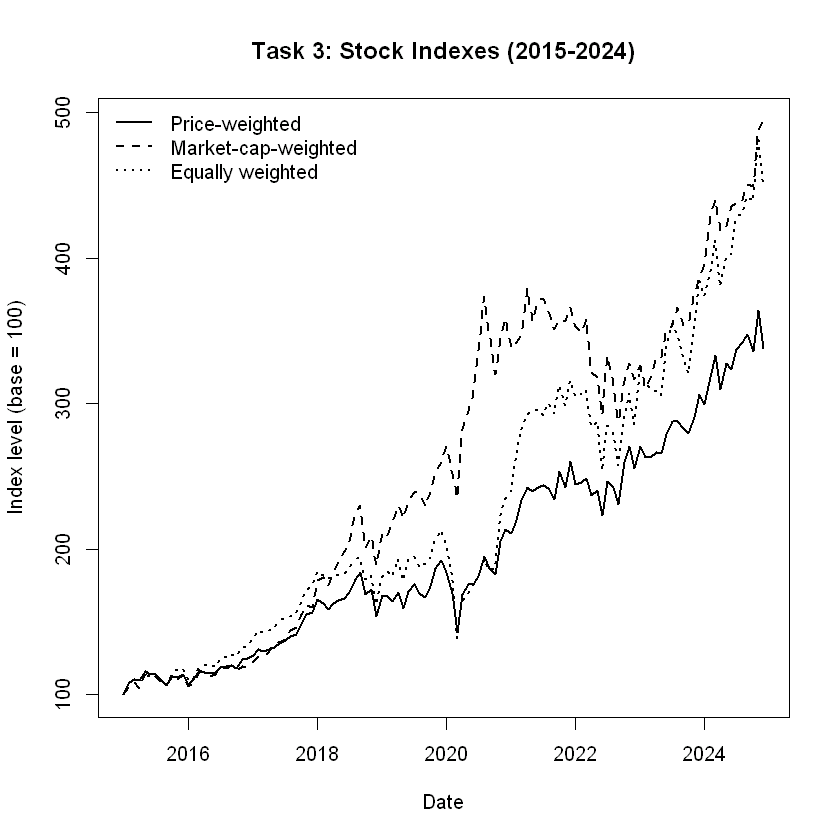

In [33]:
# ------------------------------
# STEP 9: final plot
# ------------------------------
plot_dates <- as.Date(paste0(index_table$ym, "-01"))

plot(
  plot_dates, index_table$Price_Weighted_Index,
  type = "l", lwd = 2,
  xlab = "Date",
  ylab = "Index level (base = 100)",
  main = "Task 3: Stock Indexes (2015-2024)",
  ylim = range(
    c(index_table$Price_Weighted_Index,
      index_table$MarketCap_Weighted_Index,
      index_table$Equal_Weighted_Index)
  )
)

lines(plot_dates, index_table$MarketCap_Weighted_Index, lwd = 2, lty = 2)
lines(plot_dates, index_table$Equal_Weighted_Index, lwd = 2, lty = 3)

legend(
  "topleft",
  legend = c("Price-weighted", "Market-cap-weighted", "Equally weighted"),
  lty = c(1, 2, 3),
  lwd = c(2, 2, 2),
  bty = "n"
)

In [34]:
# ------------------------------
# TASK 3 - STEP 10: summary for interpretation
# ------------------------------
index_summary <- data.frame(
  Index = c("Price-weighted", "Market-cap-weighted", "Equally weighted"),
  Final_Value = c(
    tail(index_table$Price_Weighted_Index, 1),
    tail(index_table$MarketCap_Weighted_Index, 1),
    tail(index_table$Equal_Weighted_Index, 1)
  ),
  Total_Growth_Percent = c(
    (tail(index_table$Price_Weighted_Index, 1) / index_table$Price_Weighted_Index[1] - 1) * 100,
    (tail(index_table$MarketCap_Weighted_Index, 1) / index_table$MarketCap_Weighted_Index[1] - 1) * 100,
    (tail(index_table$Equal_Weighted_Index, 1) / index_table$Equal_Weighted_Index[1] - 1) * 100
  )
)

index_summary

Index,Final_Value,Total_Growth_Percent
<chr>,<dbl>,<dbl>
Price-weighted,338.1240,238.1240
Market-cap-weighted,493.9142,393.9142
Equally weighted,450.3522,350.3522


### Interpretation of the results

The final graph shows clear differences across the three weighting schemes. The market-cap-weighted index performs best over the sample and reaches the highest final value, indicating that the largest firms in the portfolio contributed most strongly to overall index growth. The equally weighted index also performs strongly, but it remains below the market-cap-weighted index because all firms receive the same importance regardless of size. The price-weighted index grows the least, which suggests that weighting stocks only by their price levels produces a less favorable performance path in this sample.

By the end of 2024, the market-cap-weighted index reaches approximately 493.91, the equally weighted index 450.35, and the price-weighted index 338.12. Overall, this suggests that index construction matters substantially: different weighting rules can lead to noticeably different investment outcomes even when the same underlying 20 stocks are used.